# Single Read vs Merged Read Comparison - CCB

This notebook compares MBO foil profiles from two different reading approaches:

1. **Single Read (Foil 1)**: Two detector circles captured in a single 8-shaped image
2. **Merged Read (Foils 2 & 3)**: Two separate foils merged into a single profile

Profiles are aligned so that the midpoint between circle centers is at X = 0.
Normalization is done at the left circle center (value = 1.0).

Calculated metrics:
- FWHM (Full Width at Half Maximum)
- Range (90% dose position)
- Distal falloff 80%-20%
- Distal falloff 90%-10%
- Max-to-plateau ratio

In [14]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd()
while not (project_root / 'pyproject.toml').exists() and project_root != project_root.parent:
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

## Configuration

In [16]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Data path
DATA_PATH = Path(r"C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_ccb\2026-02-20")

# File paths
SINGLE_READ_FILE = DATA_PATH / 'single_read_foil_1.npz'
MERGED_PROFILE_FILE = DATA_PATH / 'profile_foils_2_3.npz'
MERGED_CIRCLES_FILE = DATA_PATH / 'merged_foils_2_3.npz'

# Verify files exist
print(f'Single read file exists: {SINGLE_READ_FILE.exists()}')
print(f'Merged profile file exists: {MERGED_PROFILE_FILE.exists()}')
print(f'Merged circles file exists: {MERGED_CIRCLES_FILE.exists()}')

Single read file exists: True
Merged profile file exists: True
Merged circles file exists: True


## Load Data

In [17]:
# Load single read data (foil 1 - 8-shaped figure)
single_data = np.load(SINGLE_READ_FILE)

single_x_mm = single_data['profile_x_mm']
single_profile = single_data['profile_smooth']
single_pixel_size = float(single_data['pixel_size_mm'])

# Circle coordinates in rotated frame
single_circle1_x = float(single_data['circle1_x']) * single_pixel_size  # left circle
single_circle2_x = float(single_data['circle2_x']) * single_pixel_size  # right circle

print('Single Read (Foil 1):')
print(f'  X range: [{single_x_mm.min():.2f}, {single_x_mm.max():.2f}] mm')
print(f'  Left circle center X: {single_circle1_x:.2f} mm')
print(f'  Right circle center X: {single_circle2_x:.2f} mm')
print(f'  Midpoint: {(single_circle1_x + single_circle2_x) / 2:.2f} mm')

Single Read (Foil 1):
  X range: [0.00, 46.10] mm
  Left circle center X: 15.45 mm
  Right circle center X: 30.66 mm
  Midpoint: 23.05 mm


In [18]:
# Load merged read data (foils 2 & 3)
merged_profile_data = np.load(MERGED_PROFILE_FILE)
merged_circles_data = np.load(MERGED_CIRCLES_FILE)

merged_x_mm = merged_profile_data['x_mm']
merged_profile = merged_profile_data['profile_opt_smooth']
merged_pixel_size = float(merged_profile_data['pixel_size_mm'])

# Circle coordinates (optimized)
merged_left_x = float(merged_circles_data['left_circle_opt_x']) * merged_pixel_size
merged_right_x = float(merged_circles_data['right_circle_opt_x']) * merged_pixel_size

print('Merged Read (Foils 2 & 3):')
print(f'  X range: [{merged_x_mm.min():.2f}, {merged_x_mm.max():.2f}] mm')
print(f'  Left circle center X: {merged_left_x:.2f} mm')
print(f'  Right circle center X: {merged_right_x:.2f} mm')
print(f'  Midpoint: {(merged_left_x + merged_right_x) / 2:.2f} mm')

Merged Read (Foils 2 & 3):
  X range: [0.00, 37.44] mm
  Left circle center X: 11.22 mm
  Right circle center X: 26.40 mm
  Midpoint: 18.81 mm


## Align Profiles

Shift X coordinates so that the midpoint between circle centers is at X = 0.

In [19]:
# Calculate midpoints
single_midpoint = (single_circle1_x + single_circle2_x) / 2
merged_midpoint = (merged_left_x + merged_right_x) / 2

# Shift X coordinates so midpoint = 0
single_x_aligned = single_x_mm - single_midpoint
merged_x_aligned = merged_x_mm - merged_midpoint

# Calculate aligned left circle positions (for normalization)
single_left_center_aligned = single_circle1_x - single_midpoint
merged_left_center_aligned = merged_left_x - merged_midpoint

print('Alignment check:')
print(f'  Single read: midpoint shift = {single_midpoint:.2f} mm')
print(f'  Merged read: midpoint shift = {merged_midpoint:.2f} mm')
print(f'\nLeft circle centers (relative to midpoint):')
print(f'  Single read: {single_left_center_aligned:.2f} mm')
print(f'  Merged read: {merged_left_center_aligned:.2f} mm')

Alignment check:
  Single read: midpoint shift = 23.05 mm
  Merged read: midpoint shift = 18.81 mm

Left circle centers (relative to midpoint):
  Single read: -7.61 mm
  Merged read: -7.59 mm


## Raw Signal Comparison

Profile comparison without normalization, using raw signal values.

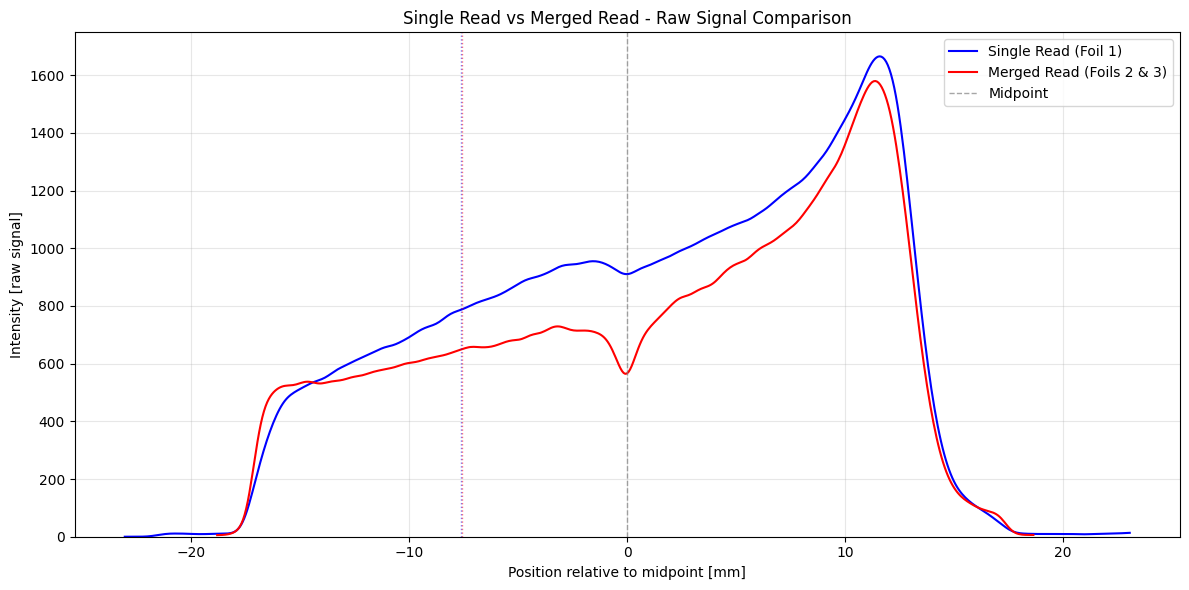

In [20]:
# Raw signal comparison (without normalization)
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(single_x_aligned, single_profile, color='blue', label='Single Read (Foil 1)', linewidth=1.5)
ax.plot(merged_x_aligned, merged_profile, color='red', label='Merged Read (Foils 2 & 3)', linewidth=1.5)

# Mark midpoint
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Midpoint')

# Mark left circle center positions
ax.axvline(x=single_left_center_aligned, color='blue', linestyle=':', linewidth=1, alpha=0.5)
ax.axvline(x=merged_left_center_aligned, color='red', linestyle=':', linewidth=1, alpha=0.5)

ax.set_xlabel('Position relative to midpoint [mm]')
ax.set_ylabel('Intensity [raw signal]')
ax.set_title('Single Read vs Merged Read - Raw Signal Comparison')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, None)

plt.tight_layout()
plt.show()

## Normalize Profiles

Normalize profiles so that the value at the left circle center equals 1.0.

In [21]:
def get_interpolated_value(x_arr, profile, target_x):
    """Get interpolated profile value at target_x position."""
    interp_func = interp1d(x_arr, profile, kind='linear', fill_value='extrapolate')
    return float(interp_func(target_x))


# Get values at left circle center for normalization
single_norm_value = get_interpolated_value(single_x_aligned, single_profile, single_left_center_aligned)
merged_norm_value = get_interpolated_value(merged_x_aligned, merged_profile, merged_left_center_aligned)

print(f'Normalization values (at left circle center):')
print(f'  Single read: {single_norm_value:.2f} at X = {single_left_center_aligned:.2f} mm')
print(f'  Merged read: {merged_norm_value:.2f} at X = {merged_left_center_aligned:.2f} mm')

# Normalize profiles
single_profile_norm = single_profile / single_norm_value
merged_profile_norm = merged_profile / merged_norm_value

print(f'\nNormalized profile ranges:')
print(f'  Single read: [{single_profile_norm.min():.3f}, {single_profile_norm.max():.3f}]')
print(f'  Merged read: [{merged_profile_norm.min():.3f}, {merged_profile_norm.max():.3f}]')

Normalization values (at left circle center):
  Single read: 787.60 at X = -7.61 mm
  Merged read: 650.04 at X = -7.59 mm

Normalized profile ranges:
  Single read: [0.000, 2.115]
  Merged read: [0.009, 2.431]


## Profile Metrics Functions

In [22]:
def find_fwhm_boundaries(profile, x_mm):
    """Find left and right FWHM boundaries."""
    max_val = np.max(profile)
    max_idx = np.argmax(profile)
    half_max = max_val / 2
    
    left_pos = None
    right_pos = None
    
    # Left side (before max)
    for i in range(max_idx - 1, -1, -1):
        if profile[i] < half_max <= profile[i + 1]:
            frac = (half_max - profile[i]) / (profile[i + 1] - profile[i])
            left_pos = x_mm[i] + frac * (x_mm[i + 1] - x_mm[i])
            break
    
    # Right side (after max)
    for i in range(max_idx, len(profile) - 1):
        if profile[i] >= half_max > profile[i + 1]:
            frac = (half_max - profile[i]) / (profile[i + 1] - profile[i])
            right_pos = x_mm[i] + frac * (x_mm[i + 1] - x_mm[i])
            break
    
    return left_pos, right_pos, half_max


def find_distal_percent_position(profile, x_mm, target_percent):
    """Find distal position where dose drops to target_percent of max."""
    max_val = np.max(profile)
    max_idx = np.argmax(profile)
    target_val = max_val * target_percent / 100.0
    
    # Search on distal (right) side after max
    for i in range(max_idx, len(profile) - 1):
        if profile[i] >= target_val > profile[i + 1]:
            # Linear interpolation
            frac = (target_val - profile[i]) / (profile[i + 1] - profile[i])
            x_pos = x_mm[i] + frac * (x_mm[i + 1] - x_mm[i])
            return x_pos, target_val
    return None, None


def calculate_profile_metrics(profile, x_mm):
    """Calculate FWHM, distal falloff distances, and max-to-plateau ratio."""
    max_val = np.max(profile)
    max_idx = np.argmax(profile)
    
    # Normalize profile for percentage calculations
    profile_norm = profile / max_val * 100
    
    # FWHM: find positions where profile crosses 50%
    half_max = 50.0
    left_idx = None
    right_idx = None
    
    # Left side (before max)
    for i in range(max_idx - 1, -1, -1):
        if profile_norm[i] < half_max <= profile_norm[i + 1]:
            frac = (half_max - profile_norm[i]) / (profile_norm[i + 1] - profile_norm[i])
            left_idx = x_mm[i] + frac * (x_mm[i + 1] - x_mm[i])
            break
    
    # Right side (after max) - distal
    for i in range(max_idx, len(profile_norm) - 1):
        if profile_norm[i] >= half_max > profile_norm[i + 1]:
            frac = (half_max - profile_norm[i]) / (profile_norm[i + 1] - profile_norm[i])
            right_idx = x_mm[i] + frac * (x_mm[i + 1] - x_mm[i])
            break
    
    fwhm = right_idx - left_idx if (left_idx is not None and right_idx is not None) else np.nan
    
    # Distal falloff: find positions for different percentages
    def find_distal_position(target_percent):
        for i in range(max_idx, len(profile_norm) - 1):
            if profile_norm[i] >= target_percent > profile_norm[i + 1]:
                frac = (target_percent - profile_norm[i]) / (profile_norm[i + 1] - profile_norm[i])
                return x_mm[i] + frac * (x_mm[i + 1] - x_mm[i])
        return np.nan
    
    pos_90 = find_distal_position(90.0)
    pos_80 = find_distal_position(80.0)
    pos_20 = find_distal_position(20.0)
    pos_10 = find_distal_position(10.0)
    
    dist_90_10 = pos_10 - pos_90 if not (np.isnan(pos_90) or np.isnan(pos_10)) else np.nan
    dist_80_20 = pos_20 - pos_80 if not (np.isnan(pos_80) or np.isnan(pos_20)) else np.nan
    
    # Max-to-plateau ratio: max / value at entrance (first point)
    # Find entrance value (leftmost point with significant signal)
    entrance_val = profile[0] if profile[0] > 0 else profile[profile > 0][0]
    max_to_plateau = max_val / entrance_val if entrance_val > 0 else np.nan
    
    return {
        'fwhm': fwhm,
        'fwhm_left': left_idx,
        'fwhm_right': right_idx,
        'pos_90': pos_90,
        'pos_80': pos_80,
        'pos_20': pos_20,
        'pos_10': pos_10,
        'dist_90_10': dist_90_10,
        'dist_80_20': dist_80_20,
        'max_val': max_val,
        'max_to_plateau': max_to_plateau
    }

## Calculate Metrics

In [23]:
# Calculate metrics for both profiles
metrics_single = calculate_profile_metrics(single_profile_norm, single_x_aligned)
metrics_merged = calculate_profile_metrics(merged_profile_norm, merged_x_aligned)

print('Single Read (Foil 1) Metrics:')
print(f'  FWHM: {metrics_single["fwhm"]:.2f} mm')
print(f'  Range (90%): {metrics_single["pos_90"]:.2f} mm')
print(f'  Distal falloff 80%-20%: {metrics_single["dist_80_20"]:.2f} mm')
print(f'  Distal falloff 90%-10%: {metrics_single["dist_90_10"]:.2f} mm')
print(f'  Max-to-plateau: {metrics_single["max_to_plateau"]:.2f}')

print('\nMerged Read (Foils 2 & 3) Metrics:')
print(f'  FWHM: {metrics_merged["fwhm"]:.2f} mm')
print(f'  Range (90%): {metrics_merged["pos_90"]:.2f} mm')
print(f'  Distal falloff 80%-20%: {metrics_merged["dist_80_20"]:.2f} mm')
print(f'  Distal falloff 90%-10%: {metrics_merged["dist_90_10"]:.2f} mm')
print(f'  Max-to-plateau: {metrics_merged["max_to_plateau"]:.2f}')

Single Read (Foil 1) Metrics:
  FWHM: 19.49 mm
  Range (90%): 12.39 mm
  Distal falloff 80%-20%: 1.69 mm
  Distal falloff 90%-10%: 2.79 mm
  Max-to-plateau: 79268668.05

Merged Read (Foils 2 & 3) Metrics:
  FWHM: 11.43 mm
  Range (90%): 12.19 mm
  Distal falloff 80%-20%: 1.76 mm
  Distal falloff 90%-10%: 2.91 mm
  Max-to-plateau: 283.50


## Profile Comparison Plot

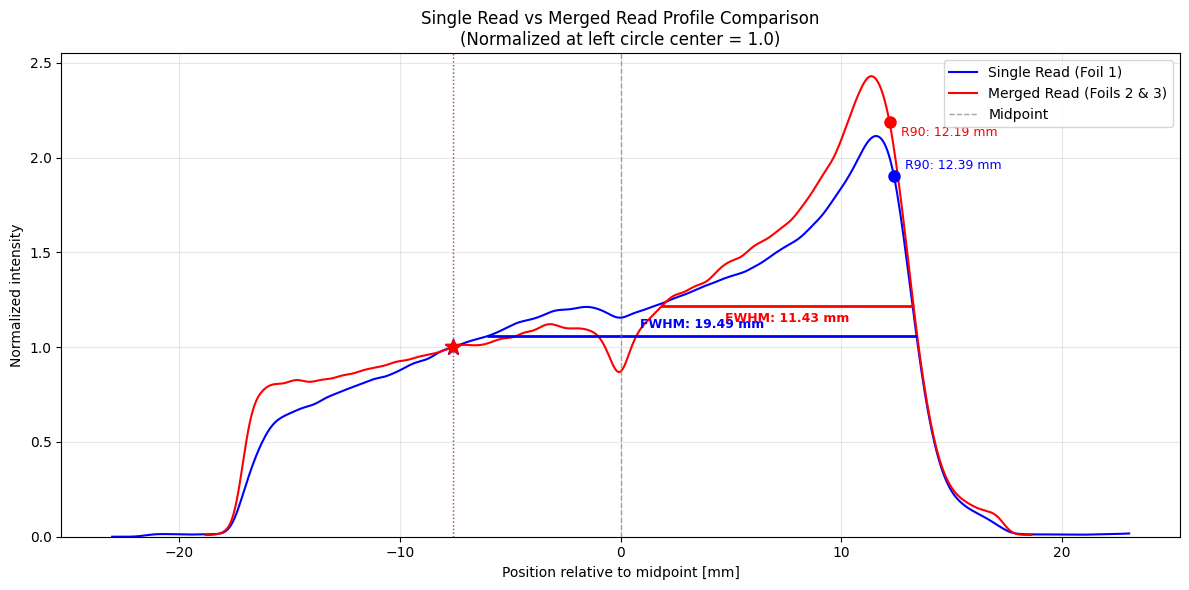

In [24]:
# Main comparison plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot profiles
ax.plot(single_x_aligned, single_profile_norm, color='blue', label='Single Read (Foil 1)', linewidth=1.5)
ax.plot(merged_x_aligned, merged_profile_norm, color='red', label='Merged Read (Foils 2 & 3)', linewidth=1.5)

# Add FWHM horizontal segments
# Single read FWHM (blue)
if metrics_single['fwhm_left'] is not None and metrics_single['fwhm_right'] is not None:
    hm_single = metrics_single['max_val'] / 2
    ax.hlines(y=hm_single, xmin=metrics_single['fwhm_left'], xmax=metrics_single['fwhm_right'], 
              color='blue', linewidth=2, linestyle='-')
    ax.text((metrics_single['fwhm_left'] + metrics_single['fwhm_right']) / 2, hm_single + 0.03, 
            f'FWHM: {metrics_single["fwhm"]:.2f} mm', 
            ha='center', va='bottom', color='blue', fontsize=9, fontweight='bold')

# Merged read FWHM (red)
if metrics_merged['fwhm_left'] is not None and metrics_merged['fwhm_right'] is not None:
    hm_merged = metrics_merged['max_val'] / 2
    ax.hlines(y=hm_merged, xmin=metrics_merged['fwhm_left'], xmax=metrics_merged['fwhm_right'], 
              color='red', linewidth=2, linestyle='-')
    ax.text((metrics_merged['fwhm_left'] + metrics_merged['fwhm_right']) / 2, hm_merged - 0.03, 
            f'FWHM: {metrics_merged["fwhm"]:.2f} mm', 
            ha='center', va='top', color='red', fontsize=9, fontweight='bold')

# Add 90% markers (Range)
if not np.isnan(metrics_single['pos_90']):
    val_90_single = metrics_single['max_val'] * 0.9
    ax.plot(metrics_single['pos_90'], val_90_single, 'o', color='blue', markersize=8)
    ax.text(metrics_single['pos_90'] + 0.5, val_90_single + 0.02, f'R90: {metrics_single["pos_90"]:.2f} mm', 
            ha='left', va='bottom', color='blue', fontsize=9)

if not np.isnan(metrics_merged['pos_90']):
    val_90_merged = metrics_merged['max_val'] * 0.9
    ax.plot(metrics_merged['pos_90'], val_90_merged, 'o', color='red', markersize=8)
    ax.text(metrics_merged['pos_90'] + 0.5, val_90_merged - 0.02, f'R90: {metrics_merged["pos_90"]:.2f} mm', 
            ha='left', va='top', color='red', fontsize=9)

# Mark midpoint (X = 0)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Midpoint')

# Mark normalization point (left circle center)
ax.axvline(x=single_left_center_aligned, color='blue', linestyle=':', linewidth=1, alpha=0.5)
ax.axvline(x=merged_left_center_aligned, color='red', linestyle=':', linewidth=1, alpha=0.5)
ax.plot(single_left_center_aligned, 1.0, 'b*', markersize=12)
ax.plot(merged_left_center_aligned, 1.0, 'r*', markersize=12)

ax.set_xlabel('Position relative to midpoint [mm]')
ax.set_ylabel('Normalized intensity')
ax.set_title('Single Read vs Merged Read Profile Comparison\n(Normalized at left circle center = 1.0)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, None)

plt.tight_layout()
plt.show()

## Distal Falloff Detail

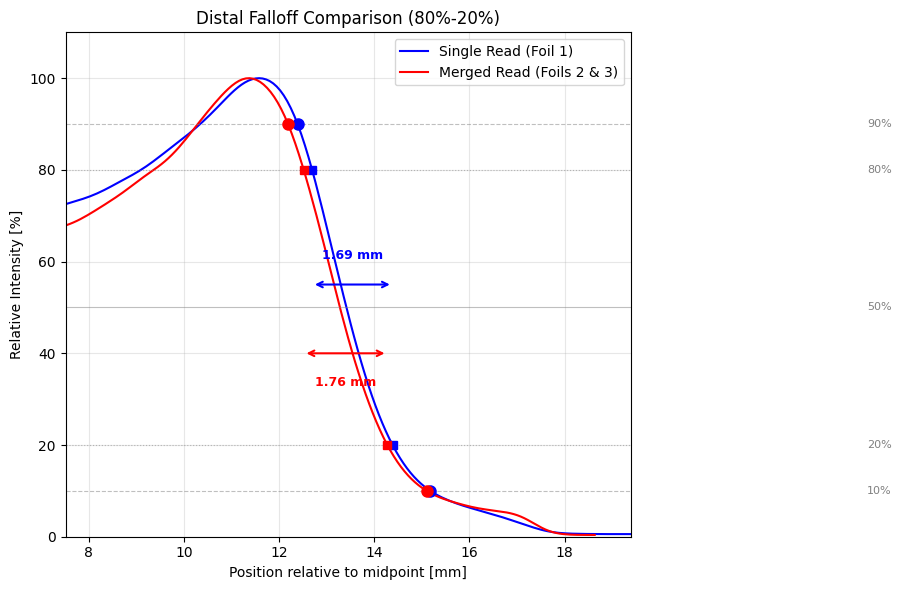

In [25]:
# Detailed distal falloff comparison (normalized to percentage of max)
fig, ax = plt.subplots(figsize=(10, 6))

# Normalize to percentage of max
single_pct = single_profile_norm / metrics_single['max_val'] * 100
merged_pct = merged_profile_norm / metrics_merged['max_val'] * 100

ax.plot(single_x_aligned, single_pct, color='blue', label='Single Read (Foil 1)', linewidth=1.5)
ax.plot(merged_x_aligned, merged_pct, color='red', label='Merged Read (Foils 2 & 3)', linewidth=1.5)

# Add horizontal lines at key percentage levels
for level, style in [(90, '--'), (80, ':'), (50, '-'), (20, ':'), (10, '--')]:
    ax.axhline(y=level, color='gray', linestyle=style, linewidth=0.8, alpha=0.5)
    ax.text(ax.get_xlim()[1] - 1, level, f'{level}%', va='center', fontsize=8, color='gray')

# Add markers at key positions - Single read
if not np.isnan(metrics_single['pos_90']):
    ax.plot(metrics_single['pos_90'], 90, 'bo', markersize=8)
    ax.plot(metrics_single['pos_80'], 80, 'bs', markersize=6)
    ax.plot(metrics_single['pos_20'], 20, 'bs', markersize=6)
    ax.plot(metrics_single['pos_10'], 10, 'bo', markersize=8)
    
    # Annotate distal falloff distance 80-20%
    mid_x_single = (metrics_single['pos_80'] + metrics_single['pos_20']) / 2
    ax.annotate('', xy=(metrics_single['pos_20'], 55), xytext=(metrics_single['pos_80'], 55),
                arrowprops=dict(arrowstyle='<->', color='blue', lw=1.5))
    ax.text(mid_x_single, 60, f'{metrics_single["dist_80_20"]:.2f} mm', 
            ha='center', va='bottom', color='blue', fontsize=9, fontweight='bold')

# Add markers at key positions - Merged read
if not np.isnan(metrics_merged['pos_90']):
    ax.plot(metrics_merged['pos_90'], 90, 'ro', markersize=8)
    ax.plot(metrics_merged['pos_80'], 80, 'rs', markersize=6)
    ax.plot(metrics_merged['pos_20'], 20, 'rs', markersize=6)
    ax.plot(metrics_merged['pos_10'], 10, 'ro', markersize=8)
    
    # Annotate distal falloff distance 80-20%
    mid_x_merged = (metrics_merged['pos_80'] + metrics_merged['pos_20']) / 2
    ax.annotate('', xy=(metrics_merged['pos_20'], 40), xytext=(metrics_merged['pos_80'], 40),
                arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))
    ax.text(mid_x_merged, 35, f'{metrics_merged["dist_80_20"]:.2f} mm', 
            ha='center', va='top', color='red', fontsize=9, fontweight='bold')

ax.set_xlabel('Position relative to midpoint [mm]')
ax.set_ylabel('Relative Intensity [%]')
ax.set_title('Distal Falloff Comparison (80%-20%)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 110)

# Zoom to distal region
distal_x_min = min(metrics_single['pos_80'], metrics_merged['pos_80']) - 5 if not np.isnan(metrics_single['pos_80']) else 10
distal_x_max = max(metrics_single['pos_20'], metrics_merged['pos_20']) + 5 if not np.isnan(metrics_single['pos_20']) else 30
ax.set_xlim(distal_x_min, distal_x_max)

plt.tight_layout()
plt.show()

## Profile Metrics Summary

In [26]:
# Display summary table
print('=' * 75)
print('SINGLE READ vs MERGED READ PROFILE METRICS COMPARISON')
print('=' * 75)
print(f'{"Metric":<30} {"Single Read":>15} {"Merged Read":>15} {"Difference":>12}')
print('-' * 75)

# FWHM
diff_fwhm = metrics_single['fwhm'] - metrics_merged['fwhm']
print(f'{"FWHM [mm]":<30} {metrics_single["fwhm"]:>15.2f} {metrics_merged["fwhm"]:>15.2f} {diff_fwhm:>12.2f}')

# Range (90%)
diff_90 = metrics_single['pos_90'] - metrics_merged['pos_90']
print(f'{"Range (90%) [mm]":<30} {metrics_single["pos_90"]:>15.2f} {metrics_merged["pos_90"]:>15.2f} {diff_90:>12.2f}')

# Distal falloff 80-20%
diff_80_20 = metrics_single['dist_80_20'] - metrics_merged['dist_80_20']
print(f'{"Distal falloff 80%-20% [mm]":<30} {metrics_single["dist_80_20"]:>15.2f} {metrics_merged["dist_80_20"]:>15.2f} {diff_80_20:>12.2f}')

# Distal falloff 90-10%
diff_90_10 = metrics_single['dist_90_10'] - metrics_merged['dist_90_10']
print(f'{"Distal falloff 90%-10% [mm]":<30} {metrics_single["dist_90_10"]:>15.2f} {metrics_merged["dist_90_10"]:>15.2f} {diff_90_10:>12.2f}')

# Max-to-plateau
diff_mtp = metrics_single['max_to_plateau'] - metrics_merged['max_to_plateau']
print(f'{"Max-to-plateau ratio":<30} {metrics_single["max_to_plateau"]:>15.2f} {metrics_merged["max_to_plateau"]:>15.2f} {diff_mtp:>12.2f}')

print('-' * 75)

print('\n--- Detailed Distal Positions ---')
print(f'{"Dataset":<15} {"90% [mm]":>12} {"80% [mm]":>12} {"20% [mm]":>12} {"10% [mm]":>12}')
print('-' * 65)
print(f'{"Single Read":<15} {metrics_single["pos_90"]:>12.2f} {metrics_single["pos_80"]:>12.2f} {metrics_single["pos_20"]:>12.2f} {metrics_single["pos_10"]:>12.2f}')
print(f'{"Merged Read":<15} {metrics_merged["pos_90"]:>12.2f} {metrics_merged["pos_80"]:>12.2f} {metrics_merged["pos_20"]:>12.2f} {metrics_merged["pos_10"]:>12.2f}')

SINGLE READ vs MERGED READ PROFILE METRICS COMPARISON
Metric                             Single Read     Merged Read   Difference
---------------------------------------------------------------------------
FWHM [mm]                                19.49           11.43         8.06
Range (90%) [mm]                         12.39           12.19         0.20
Distal falloff 80%-20% [mm]               1.69            1.76        -0.07
Distal falloff 90%-10% [mm]               2.79            2.91        -0.12
Max-to-plateau ratio               79268668.05          283.50  79268384.55
---------------------------------------------------------------------------

--- Detailed Distal Positions ---
Dataset             90% [mm]     80% [mm]     20% [mm]     10% [mm]
-----------------------------------------------------------------
Single Read            12.39        12.69        14.39        15.18
Merged Read            12.19        12.52        14.27        15.10
